## importing libraries

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import MDS, TSNE
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

## Loading the spotify dataset

In [19]:
df=pd.read_csv('dataset.csv')

## Feature engineering

In [20]:
df.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [21]:
df.shape

(114000, 21)

In [22]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [23]:
Features=[
    'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'valence', 'tempo', 'duration_ms', 'popularity'
]

In [24]:
df= df.dropna(subset=Features + ['track_genre'])
df=df.drop_duplicates(subset=['track_id'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 89741 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        89741 non-null  int64  
 1   track_id          89741 non-null  object 
 2   artists           89740 non-null  object 
 3   album_name        89740 non-null  object 
 4   track_name        89740 non-null  object 
 5   popularity        89741 non-null  int64  
 6   duration_ms       89741 non-null  int64  
 7   explicit          89741 non-null  bool   
 8   danceability      89741 non-null  float64
 9   energy            89741 non-null  float64
 10  key               89741 non-null  int64  
 11  loudness          89741 non-null  float64
 12  mode              89741 non-null  int64  
 13  speechiness       89741 non-null  float64
 14  acousticness      89741 non-null  float64
 15  instrumentalness  89741 non-null  float64
 16  liveness          89741 non-null  float64
 1

In [30]:
TOP_N=8
top_genres=df['track_genre'].value_counts().head(TOP_N).index.tolist()
df=df[df['track_genre'].isin(top_genres)].copy()
print(f"filtered: {len(df)} tracks, {TOP_N} genres")

#stractified sub samples

N_TOTAL=1200
per_genre=N_TOTAL//TOP_N
df_s=(
    df.groupby('track_genre', group_keys=False)
        .apply(lambda g: g.sample(min(len(g), per_genre), random_state=42))
        .reset_index(drop=True)
)
print(f"Sampled: {len(df_s)} tracks (~{per_genre} per genre)")
X_raw=df_s[Features].values
genres=df_s['track_genre'].values

filtered: 7991 tracks, 8 genres
Sampled: 1200 tracks (~150 per genre)


C:\Users\ndhee\AppData\Local\Temp\ipykernel_15972\1408268793.py:12: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), per_genre), random_state=42))


## Standardize the data

In [31]:
scaler=StandardScaler()
X=scaler.fit_transform(X_raw)


## appling MDS

In [33]:
mds = MDS(
    n_components=2,
    dissimilarity='euclidean',
    metric=True,
    n_init=4,
    max_iter=500,
    random_state=42,
    n_jobs=-1,
)
x_mds=mds.fit_transform(X)
print(f"MDS stress : {mds.stress_:.4f}")
print('MDS output shape', x_mds.shape)

MDS stress : 733000.9710
MDS output shape (1200, 2)


## appling t_sne

In [36]:
#Distance matrix
D=euclidean_distances(X)
print(f"Distance matrix: {D.shape}")

Distance matrix: (1200, 1200)


In [43]:
tsne = TSNE(
    n_components=2,
    metric='precomputed',
    perplexity=40,
    learning_rate='auto',
    max_iter=1000,
    init='random',
    random_state=42,
    n_jobs=-1,
)
X_tsne=tsne.fit_transform(D)

## visualization

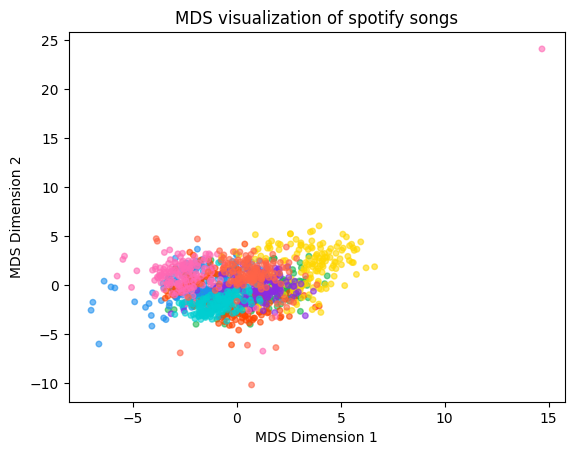

In [69]:
plt.figure()
plt.scatter(x_mds[:,0], x_mds[:,1], alpha=0.6, c=point_colors, s=16)
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('MDS visualization of spotify songs')
plt.show()

In [48]:
PALETTE=[
    '#1DB954', '#1E90EF', '#FF4500', '#FFD700', '#8A2BE2', '#FF69B4', '#00CED1', '#FF6347'
]
genre_list = sorted(top_genres)
color_map= {g: PALETTE[i] for i, g in enumerate(genre_list)}
point_colors=[color_map[g] for g in genres]

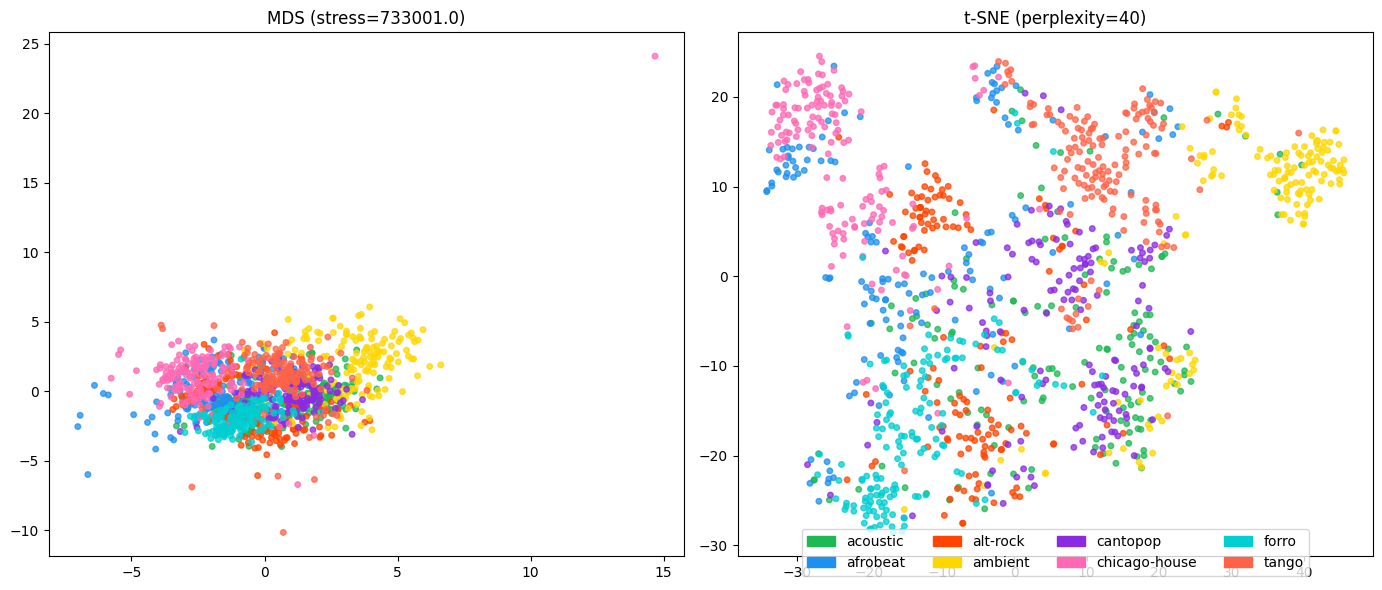

In [56]:
fig, axes= plt.subplots(1,2, figsize=(14,6))
for ax, coords, title in zip(axes,
    [x_mds, X_tsne],
    [f"MDS (stress={mds.stress_:.1f})", "t-SNE (perplexity=40)"]):
    ax.scatter(coords[:,0], coords[:,1], c=point_colors, s=16, alpha=0.75)
    ax.set_title(title)
handles=[mpatches.Patch(color=color_map[g], label=g) for g in genre_list]
plt.legend(handles=handles, bbox_to_anchor=(0.5, -0.05), loc='lower center', ncol=4)
plt.tight_layout()
plt.show()